In [1]:
import torch
from torch import tensor
import matplotlib.pyplot as plt
import typing 
import numpy as np
from torch.distributions import MultivariateNormal
from scipy.stats import multivariate_normal
from tqdm import tqdm

## Setup 

VE SDE: $ dx = \sqrt{\frac{d[\sigma^2(t)]}{dt}}dw $ see SDE paper


$x_0 \sim p_0(x_0)$

$x_t \sim p_t(x_t|x_0) = \mathcal{N}(x_t; x_0, \sigma^2(t) I)$

$y = A(x_0) + \sigma_y \eta$ -> this defines $p(y|x_0)$

$\hat{x}_0 \sim p_{0|t}  = \mathcal{N} (\hat{x}_0; m_{0|t}, \Sigma_{0|t})$

 -  Where for VE SDE: $m_{0|t} = x_t$, $\Sigma_{0|t} = \sigma^2_t I$

sample $\{ \hat{x}_0^{(i)}\}_{i=1}^{i=N} \sim p_{0|t}()$ to approximate $\mathbb{E}_{x_0|x_t} [p(y|x_0)]$

take gradient to compute $\nabla_{x_t} \log \mathbb{E}_{x_0|x_t} [p(y|x_0)] \approx \nabla_{x_t} \log \sum_{i=1}^N p(y|\hat{x}_0^{(i)})$

compute $ \nabla_{x_t} \log p(y|x_t)$

$x_0 \sim \mathcal{N}(0, \sigma_0^2I)$

$x_t|x_0 \sim \mathcal{N}(x_0, \sigma_t^2I)$ => $ x_t \sim \mathcal{N}(0, (\sigma_0^2 + \sigma_t^2)I) = p_t(\cdot)$

$\nabla_{x_t} \log p_t (x_t) = \frac{-x_t}{\sigma_0^2 + \sigma_t^2}$

## Mixture of Gaussians experiment

In [28]:
def A(x):
    '''observation model'''
    a = 1
    return a * torch.tanh(x/a)

def p0(x):
    mvn1 = MultivariateNormal(tensor([-1.0]), tensor(0.2**2).reshape((1,1)))
    mvn2 = MultivariateNormal(tensor([1.0]), tensor(0.5**2).reshape((1,1)))
    return 0.5 * torch.exp(mvn1.log_prob(x)) + 0.5 * torch.exp(mvn2.log_prob(x))

def sample_p0(n):
    x = torch.zeros(n)
    for i in range(n):
        if torch.rand(1) > 0.5:
            x[i] = torch.randn(1) * 0.5 + 1.0
        else:
            x[i] = torch.randn(1) * 0.2 - 1.0
    return x

def pt(x, t):
    var_t = sigmas2_total[t]
    mvn1 = MultivariateNormal(tensor([-1.0]), (0.2**2 + var_t).reshape((1,1)))
    mvn2 = MultivariateNormal(tensor([1.0]), (0.5**2 + var_t).reshape((1,1)))
    return 0.5 * torch.exp(mvn1.log_prob(x)) + 0.5 * torch.exp(mvn2.log_prob(x))

def sample_pt(t, n):
    mu1, mu2 = -1, 1
    var1_t, var2_t = 0.2**2 + sigmas2_total[t], 0.5**2 + sigmas2_total[t]
    var1_t, var2_t = var1_t.reshape((1,1)), var2_t.reshape((1,1))
    x = torch.zeros(n)
    for i in range(n):
        if torch.rand(1) > 0.5:
            x[i] = torch.randn(1) * (var1_t)**0.5 + mu1
        else:
            x[i] = torch.randn(1) * (var2_t)**0.5 + mu2
    return x

def score_pt(xt, t): # xt[samples, dims]
    # var_t = sigmas2_total[t]
    # z = pt(xt, t).reshape(xt.shape, 1) # z[samples, 1]
    # mu1, mu2 = -1, 1
    # cov1_t, cov2_t = 0.2**2 + var_t, 0.5**2 + var_t
    # mvn1 = MultivariateNormal(tensor([mu1]), cov1_t.reshape((1,1))) 
    # mvn2 = MultivariateNormal(tensor([mu2]), cov2_t.reshape((1,1)))
    # p1 = torch.exp(mvn1.log_prob(xt).reshape(xt.shape, 1)) # p1[samples, 1]
    # p2 = torch.exp(mvn2.log_prob(xt).reshape(xt.shape, 1)) # p2[samples, 1]
    # score = -0.5 *((xt+1)/(0.2**2 + var_t.item())*p1 + (xt-1)/(0.5**2 + var_t.item())*p2)/z
    log_p = torch.log(pt(xt, t))
    grads = torch.autograd.grad(log_p, xt, torch.ones_like(log_p))[0]
    return grads

In [29]:
n = 10000
T = 1
dims = 1
diff_steps = 100

sigmas2_total = torch.linspace(0, T, diff_steps+1)
ts = torch.arange(0, diff_steps+1)
del_sigmas2 = torch.diff(sigmas2_total)
del_sigmas = torch.sqrt(del_sigmas2)

xt = torch.zeros((diff_steps, n, dims)) # xt[time, samples, dims]
xt[0] = sample_p0(n).reshape((n, dims))

# forward noising process
for t in range(1, diff_steps):
    xt[t] = xt[t-1] + del_sigmas[t] * torch.randn_like(xt[t])

Text(0.5, 1.0, 'Forward process')

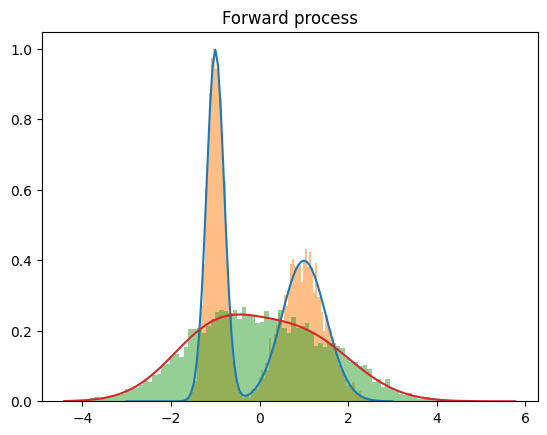

In [30]:
x = torch.linspace(-3.0, 3.0, 100).reshape((100,1))
plt.plot(x, p0(x))
_, bins, counts = plt.hist(xt[0].numpy(), bins=100, alpha = 0.5, density=True)
# _, bins, counts = plt.hist(xt[2].numpy(), bins=100, alpha = 0.5, density=True)
_, bins, counts = plt.hist(xt[-1].numpy(), bins=100, alpha = 0.5, density=True)

x = torch.linspace(xt.min(), xt.max(), 100).reshape((100,1))
plt.plot(x, pt(x, ts[-1].item()))
plt.title('Forward process')

In [31]:
# denoisisng process
xt_bwd = torch.zeros_like(xt)
xt_bwd[-1] = xt[-1].clone().detach() #xt[time, samples, dims]
for t in range(diff_steps-1, 0, -1):
    sc = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t+1])
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2 [t-1] * sc + torch.randn_like(xt_bwd[t])*del_sigmas[t-1]

Text(0.5, 1.0, 'Backwards process')

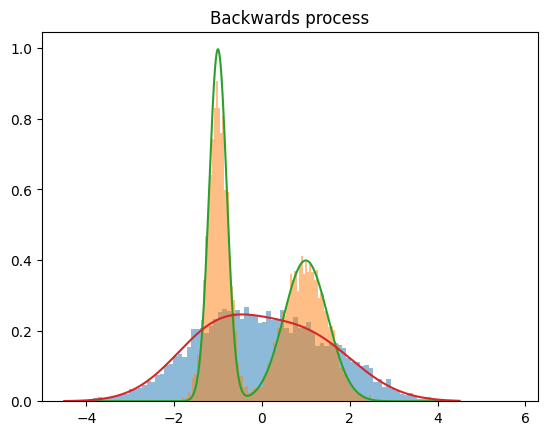

In [32]:
_ = plt.hist(xt_bwd[-1].numpy(), bins=100, alpha = 0.5, density=True)
_ = plt.hist(xt_bwd[0].numpy(), bins=100, alpha = 0.5, density=True)
x = torch.linspace(-4.5, 4.5, 1000).reshape((1000,1))
plt.plot(x, pt(x, 0))
plt.plot(x, pt(x, ts[-1]))
plt.title('Backwards process')

mena: tensor(0.0056) var: tensor(0.9950) MAE: tensor(0.7065)


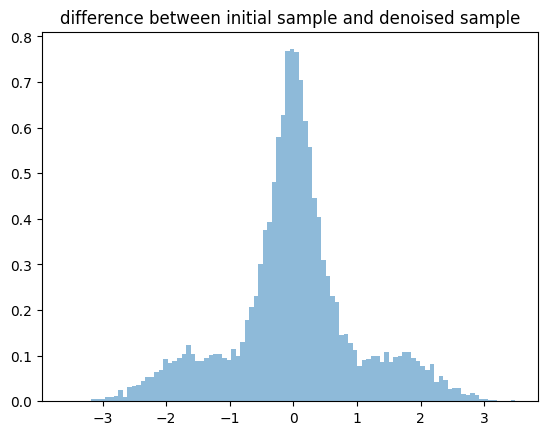

In [33]:
_ = plt.hist((xt[0] - xt_bwd[0]).clone().detach().numpy(), bins=100, alpha = 0.5, density=True)
plt.title('difference between initial sample and denoised sample')
print('mena:', (xt[0] - xt_bwd[0]).mean(),'var:', (xt[0] - xt_bwd[0]).var(), 'MAE:', torch.abs(xt[0] - xt_bwd[0]).mean())

## Mixture of Gaussians with observation

$x_0 \sim p_0(\cdot)$

$x_t = x_{t-1} + \sqrt{\sigma^2(t) - \sigma^2(t-1)} \eta$

$y = A(x_0) + \eta$

$x_{t-1} = x_{t} + \nabla_{x_t} \log p_t(x_t|y) + \sqrt{\sigma^2(t) - \sigma^2(t-1)} \eta$

$= x_{t} + \nabla_{x_t} \log p_t(y|x_t) + \nabla_{x_t} \log p_t(x_t)+ \sqrt{\sigma^2(t) - \sigma^2(t-1)} \eta$

$\nabla_{x_t} \log p_t(y|x_t) = \nabla_{x_t} \log \mathbb{E}_{x_0|x_t} [p(y|x_0)] \approx \nabla_{x_t} \log \sum_{i=1}^N p(y|\hat{x}_0^{(i)})$

In [34]:
n = 10000
T = tensor(1.0)
dims = 1
diff_steps = 100

sigmas2_total = torch.linspace(0, T, diff_steps+1)
ts = torch.arange(0, diff_steps+1, dtype = torch.int32)
del_sigmas2 = torch.diff(sigmas2_total)
del_sigmas = torch.sqrt(del_sigmas2)

xt = torch.zeros((diff_steps, n, dims)) # xt[time, samples, dims]
xt[0] = sample_p0(n).reshape((n, dims))

sigma_y = tensor(0.01).reshape((1,1))
y = A(xt[0]) + sigma_y * torch.randn_like(xt[0])

# forward noising process
for t in range(1, diff_steps):
    xt[t] = xt[t-1] + del_sigmas[t] * torch.randn_like(xt[t])

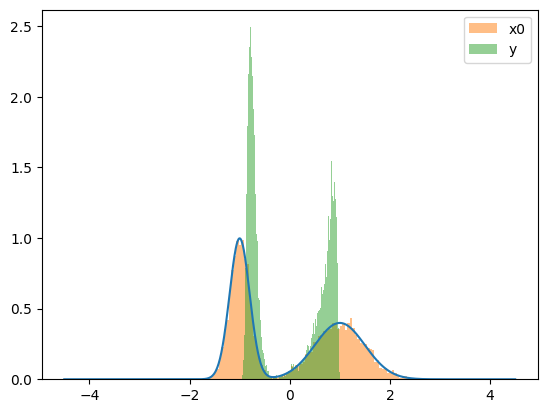

In [35]:
plt.plot(x, p0(x))
_ = plt.hist(xt[0].numpy(), bins=100, alpha = 0.5, density=True, label = 'x0')
_ = plt.hist(y.numpy(), bins=100, alpha = 0.5, density=True, label = 'y')
plt.legend()

$\nabla_{x_t} \log p_t(y|x_t) = \nabla_{x_t} \log \mathbb{E}_{x_0|x_t} [p(y|x_0)] \approx \nabla_{x_t} \log \sum_{i=1}^N p(y|\hat{x}_0^{(i)})$

In [36]:
def log_p_y_given_x(y, x):
    mvn = MultivariateNormal(A(x), sigma_y)
    return mvn.log_prob(y)

def get_mu_from_xt(xt: tensor, t = 1):
    return xt + sigmas2_total[t].item() * score_pt(xt, t)

def get_guidance(xt, y, t, n_samples = 1):
    mu = get_mu_from_xt(xt, t)
    sigma = ((sigmas2_total[t])**0.5).reshape((1,1))
    x_hats = mu + sigma * torch.randn(n_samples, *mu.shape)
    log_p_y_ests = log_p_y_given_x(y, x_hats)
    log_p_est = torch.logsumexp(log_p_y_ests, dim=0)
    grads = torch.autograd.grad(log_p_est, xt, torch.ones_like(log_p_est))[0]
    return grads, x_hats

In [37]:
xt_bwd = torch.zeros_like(xt)
xt_bwd[-1] = xt[-1].clone().detach().requires_grad_(True) #xt[time, samples, dims]
for t in range(diff_steps-1, 0, -1):
    sc = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t+1])
    guidance = 1.0 * get_guidance(xt_bwd[t], y, t, 100)[0]
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2 [t-1] * (sc + guidance) + torch.randn_like(xt_bwd[t])*del_sigmas[t-1]

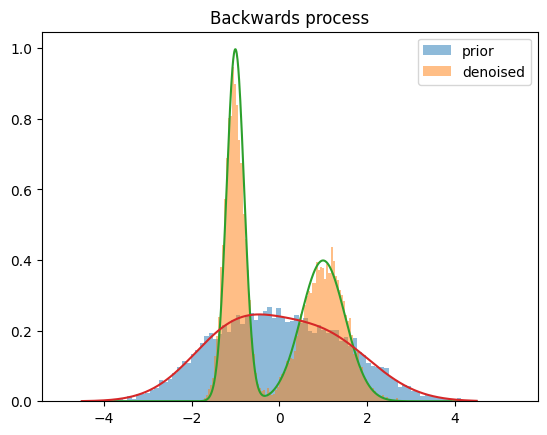

In [38]:
_ = plt.hist(xt_bwd[-1].clone().detach().numpy(), bins=100, alpha = 0.5, density=True, label ='prior' )
_ = plt.hist(xt_bwd[0].clone().detach().numpy(), bins=100, alpha = 0.5, density=True, label = 'denoised')
x = torch.linspace(-4.5, 4.5, 1000).reshape((1000,1))
plt.plot(x, pt(x, 0))
plt.plot(x, pt(x, ts[-1]))
plt.title('Backwards process')
plt.legend()

mean: tensor(0.0009, grad_fn=<MeanBackward0>) var: tensor(0.0565, grad_fn=<VarBackward0>) MAE: tensor(0.1779, grad_fn=<MeanBackward0>)


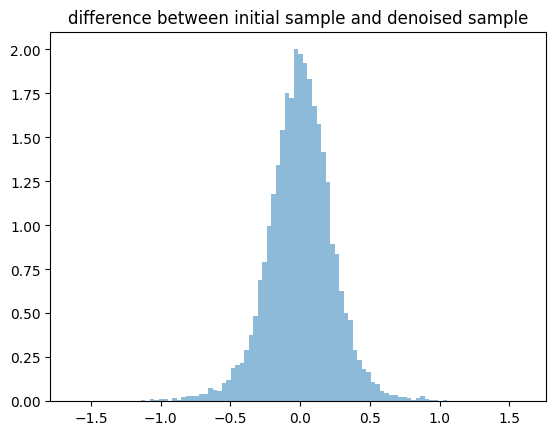

In [39]:
_ = plt.hist((xt[0] - xt_bwd[0]).clone().detach().numpy(), bins=100, alpha = 0.5, density=True)
plt.title('difference between initial sample and denoised sample')
print('mean:', (xt[0] - xt_bwd[0]).mean(), 'var:', (xt[0] - xt_bwd[0]).var(), 'MAE:', torch.abs(xt[0] - xt_bwd[0]).mean())